In [1]:
import pandas as pd 
import numpy as np 
import scipy.cluster.hierarchy as spc
import matplotlib.pyplot as plt 

def plot_corr_distrib(df_corr, title):
    plt.figure()
    corrs = df_corr.values[np.triu_indices_from(df_corr)]
    pd.Series(corrs).plot.hist(bins=30, title=title+"\ndistribution of correlation matrix")

def plot_dendro(df_coff, title, do_abs=False):
    fn_abs = lambda x: np.abs(x) if do_abs else x
    plt.figure()
    corr = df_corr.dropna(axis=0,how="all").dropna(axis=1).values
    pdist_uncondensed = 1.0 - fn_abs(corr)
    pdist_condensed = np.concatenate([row[i+1:] for i, row in enumerate(pdist_uncondensed)])
    linkage = spc.linkage(pdist_condensed, method='complete')
    dend = spc.dendrogram(
        linkage
    )
    plt.title(title+"\ndendrogram, distance = 1-abs(corr)")
    plt.show()
    # idx = spc.fcluster(linkage, 0.5 * pdist_condensed.max(), 'distance')

    sorted_indices = dend['leaves']
    corr_sorted = pd.DataFrame(fn_abs(corr)).iloc[sorted_indices, sorted_indices].values
    plt.figure()
    # plt.figure(figsize=(20, 20))
    plt.matshow(corr_sorted, fignum=1, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar()
    plt.title(title + "\nSorted Correlation Matrix", pad=20)
    plt.show()

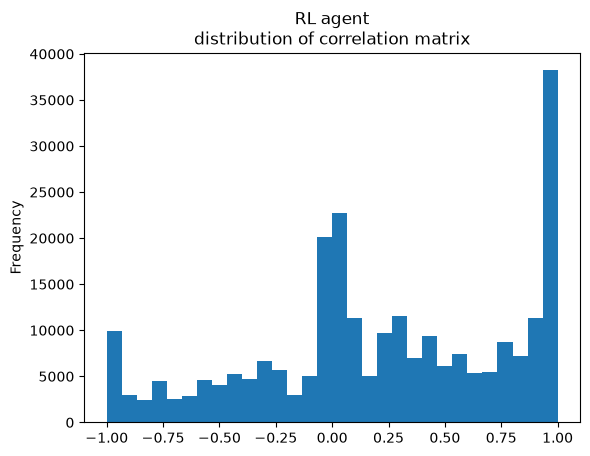

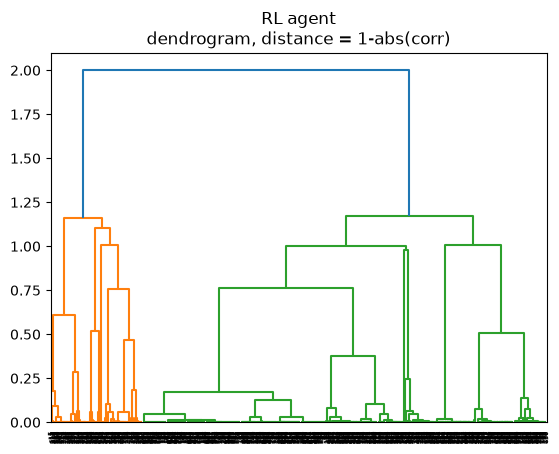

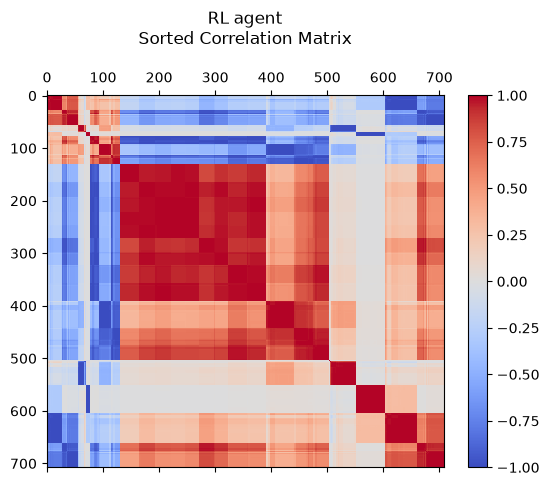

In [2]:
df = pd.read_csv("../returns_behav_2.csv", index_col=[0], header=None)
df = df.reset_index(drop=True).T
df_corr = df.iloc[:,:1000].corr() # inspect first 1000 signals
plot_corr_distrib(df_corr, "RL agent")
plot_dendro(df_corr, "RL agent")

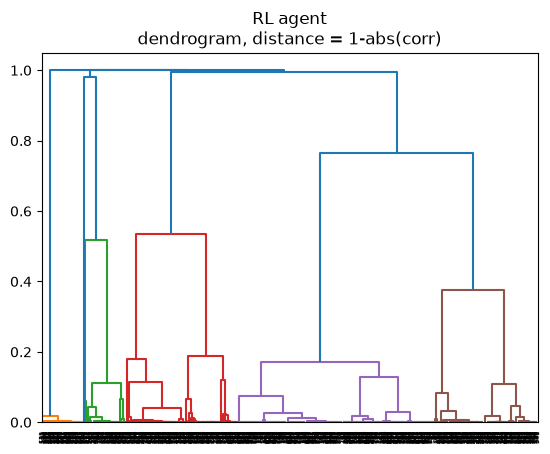

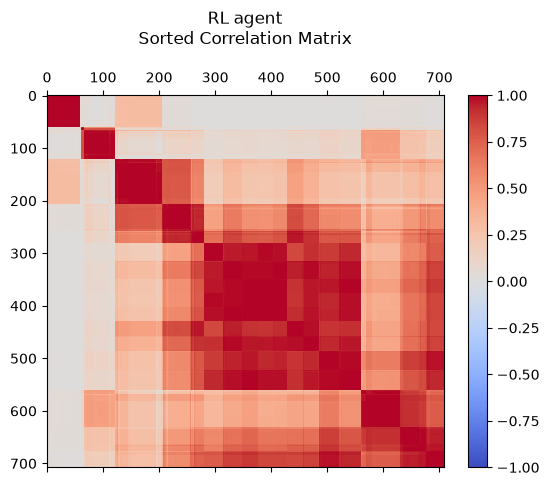

In [3]:

plot_dendro(df_corr, "RL agent", do_abs=True)

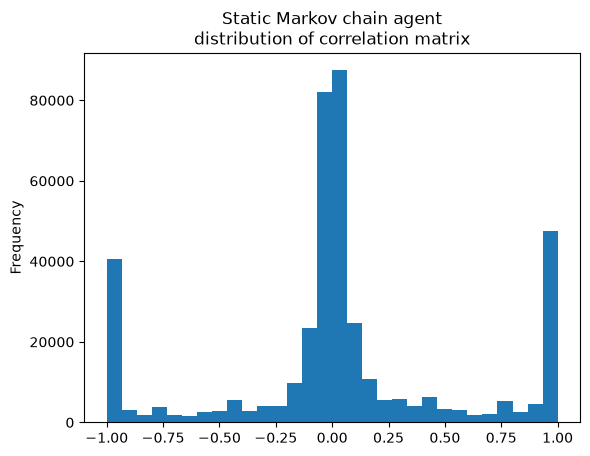

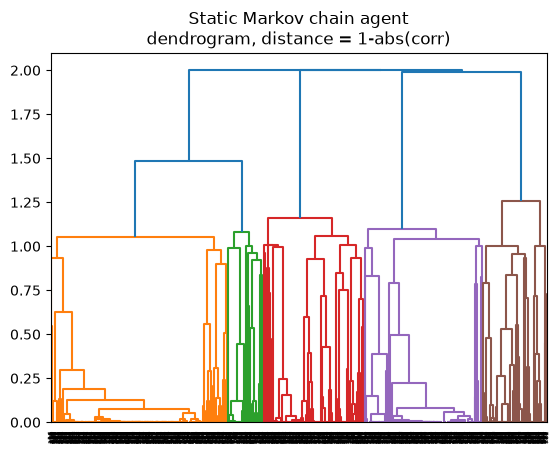

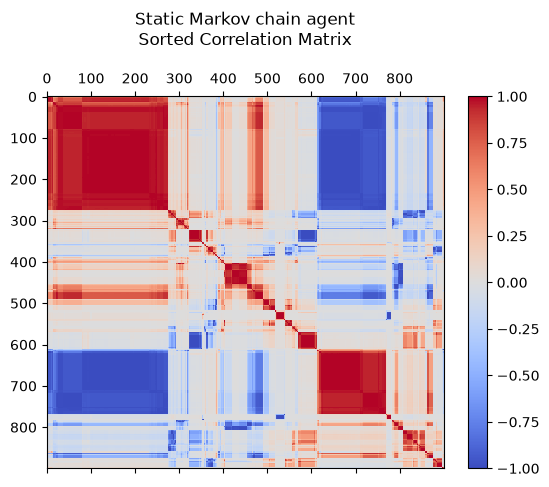

In [4]:

df = pd.read_csv("../returns_brute.csv", index_col=[0], header=None)
df = df.reset_index(drop=True).T
df_corr = df.iloc[:,:1000].corr() # inspect first 1000 signals
plot_corr_distrib(df_corr, "Static Markov chain agent")
plot_dendro(df_corr, "Static Markov chain agent")

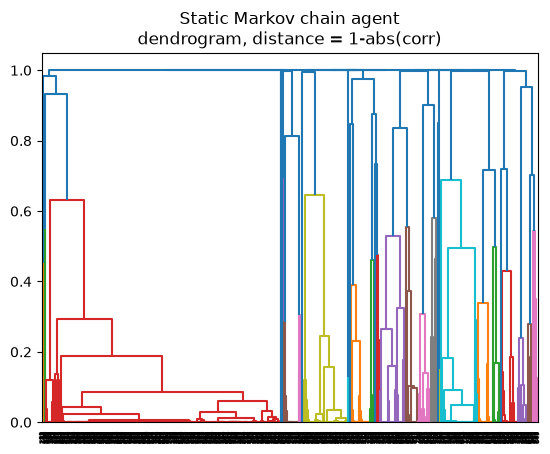

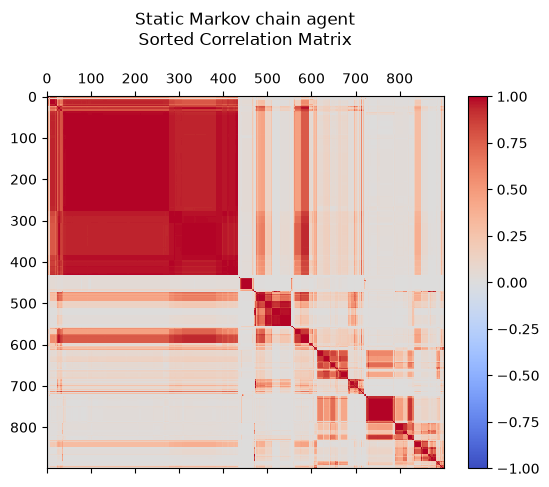

In [5]:

plot_dendro(df_corr, "Static Markov chain agent", do_abs=True)

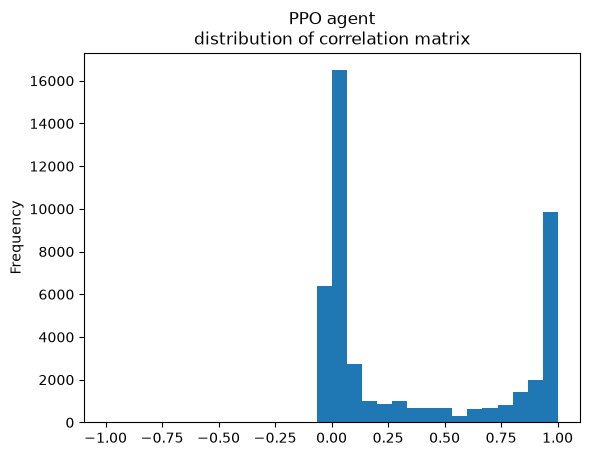

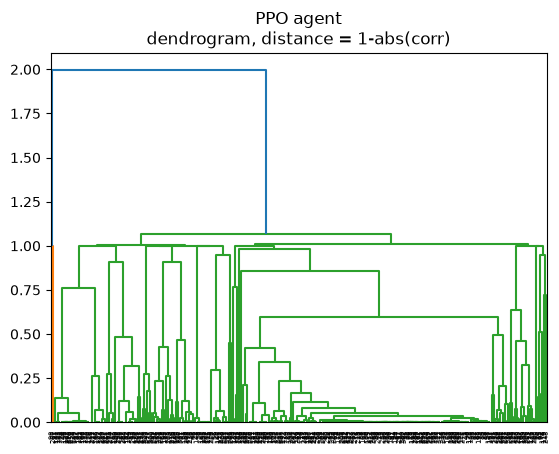

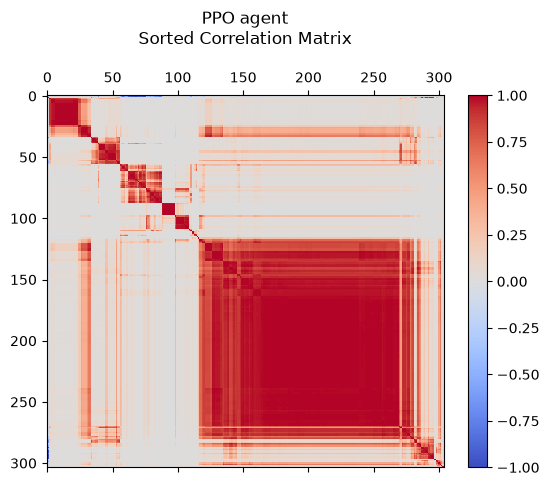

In [6]:

df = pd.read_csv("../returns_ppo.csv", index_col=[0], header=None)
df = df.reset_index(drop=True).T
df_corr = df.iloc[:,:1000].corr() # inspect first 1000 signals
plot_corr_distrib(df_corr, "PPO agent")
plot_dendro(df_corr, "PPO agent")

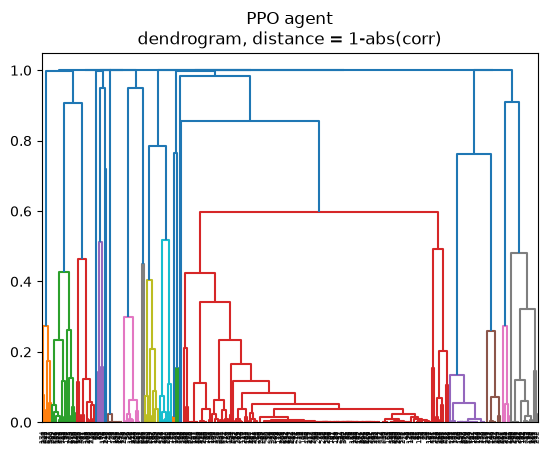

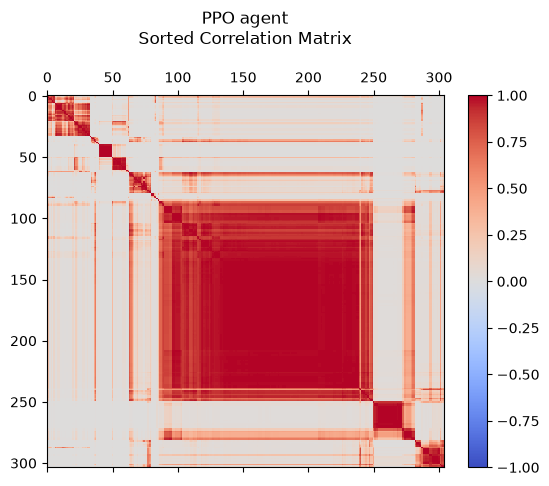

In [7]:

plot_dendro(df_corr, "PPO agent", do_abs=True)